KNN Test Accuracy: 0.9590643274853801
SVM Test Accuracy: 0.935672514619883


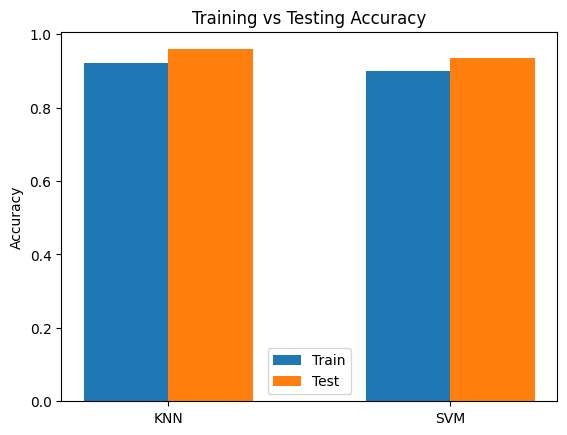

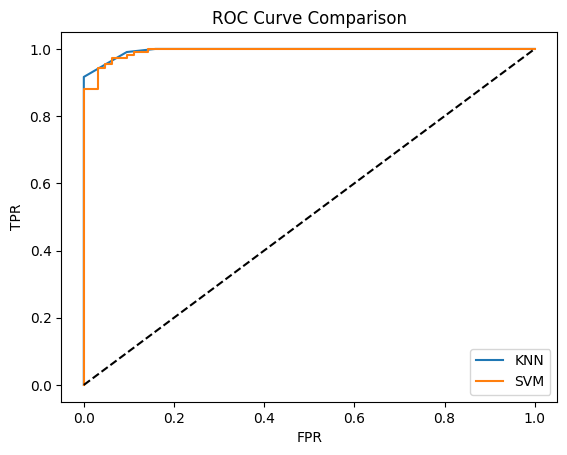

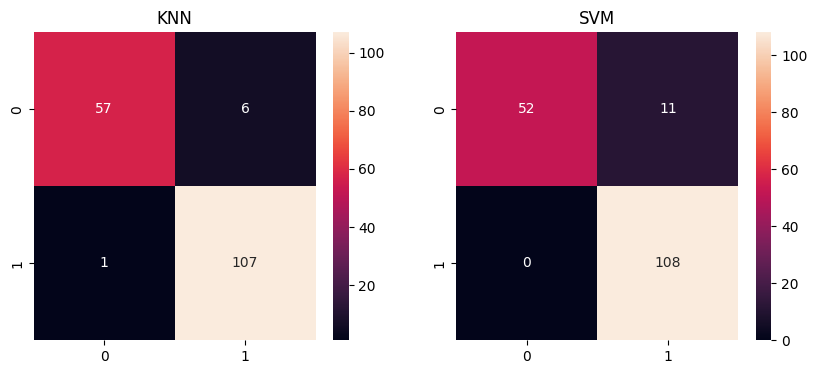

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc
)

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Models
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(probability=True)

# Train
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Predictions
y_knn = knn.predict(X_test)
y_svm = svm.predict(X_test)

# Accuracy
knn_train = accuracy_score(y_train, knn.predict(X_train))
knn_test = accuracy_score(y_test, y_knn)

svm_train = accuracy_score(y_train, svm.predict(X_train))
svm_test = accuracy_score(y_test, y_svm)

print("KNN Test Accuracy:", knn_test)
print("SVM Test Accuracy:", svm_test)

# Bar chart (train vs test)
models = ["KNN", "SVM"]
train_scores = [knn_train, svm_train]
test_scores = [knn_test, svm_test]

x = np.arange(len(models))
w = 0.3

plt.bar(x - w/2, train_scores, w, label="Train")
plt.bar(x + w/2, test_scores, w, label="Test")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.show()

# ROC Curve
y_prob_knn = knn.predict_proba(X_test)[:,1]
y_prob_svm = svm.predict_proba(X_test)[:,1]

fpr1, tpr1, _ = roc_curve(y_test, y_prob_knn)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_svm)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)

plt.plot(fpr1, tpr1, label="KNN")
plt.plot(fpr2, tpr2, label="SVM")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Confusion Matrix
cm1 = confusion_matrix(y_test, y_knn)
cm2 = confusion_matrix(y_test, y_svm)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm1, annot=True, fmt="d")
plt.title("KNN")

plt.subplot(1,2,2)
sns.heatmap(cm2, annot=True, fmt="d")
plt.title("SVM")

plt.show()